In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Colors (align with src/ts_toolkit/pipeline/visualization.py)
DARK_GREY = "#1c2b34"
SKY_BLUE = '#87CEEB'
BLUE = "#227BBB"
RED = "#B60707"
NAVY = '#000080'
GRAY = '#808080'

# Paths
RESULTS = Path("../results_shared/real_data")
df_river = pd.read_csv(RESULTS / "df_river_pred.csv", parse_dates=["datetime"])
df_nvidia = pd.read_csv(RESULTS / "df_nvidia_pred.csv", parse_dates=["Date"])

In [2]:
# MASE from legend (univariate vs with covariate), then % improvement from adding covariate
# Improvement = (MASE_uni - MASE_multi) / MASE_uni * 100  (positive = better with covariate)

mase_legend = {
    "Delaware River": {"Chronos2": (7.16, 6.74), "DLinear": (8.82, 6.69)},
    "NVIDIA": {"Chronos2": (10.56, 9.90), "DLinear": (11.29, 4.29)},
}

print("MASE improvement from adding covariate (%):\n")
print(f"{'Dataset':<18} {'Model':<12} {'MASE (uni)':<12} {'MASE (cov)':<12} {'Improvement':<12}")
print("-" * 68)
for dataset, models in mase_legend.items():
    for model, (mase_uni, mase_multi) in models.items():
        if mase_uni > 0:
            impr = (mase_uni - mase_multi) / mase_uni * 100
        else:
            impr = 0.0
        print(f"{dataset:<18} {model:<12} {mase_uni:<12.2f} {mase_multi:<12.2f} {impr:+.1f}%")

MASE improvement from adding covariate (%):

Dataset            Model        MASE (uni)   MASE (cov)   Improvement 
--------------------------------------------------------------------
Delaware River     Chronos2     7.16         6.74         +5.9%
Delaware River     DLinear      8.82         6.69         +24.1%
NVIDIA             Chronos2     10.56        9.90         +6.3%
NVIDIA             DLinear      11.29        4.29         +62.0%


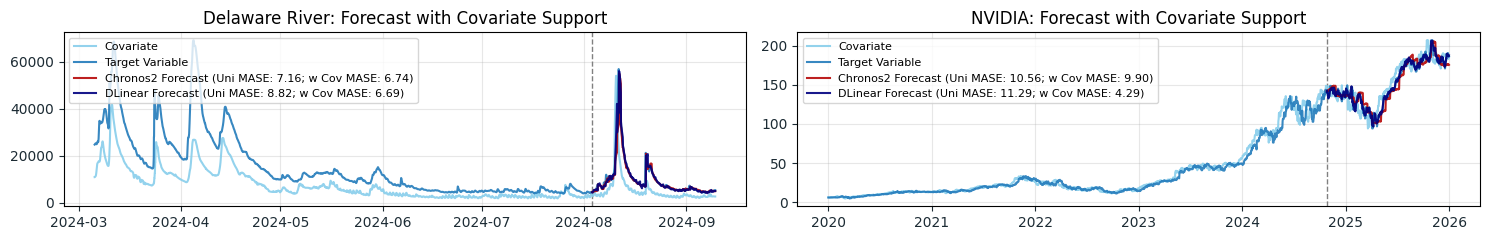

In [9]:
# Test set start = first row with a forecast
river_test_start = df_river["datetime"].iloc[df_river["forecast_chronos2_multivariate"].first_valid_index()]
nvidia_test_start = df_nvidia["Date"].iloc[df_nvidia["forecast_chronos2_multivariate"].first_valid_index()]

# Figsize aligned with visualization.py (e.g. polished_grid_plot uses (15, 5); 2x2 grid)
fig, axes = plt.subplots(1, 2, figsize=(15, 2.5))

x_r = df_river["datetime"]
# (0,1) With Covariate Support
ax = axes[0]
ax.axvline(river_test_start, color=GRAY, linestyle="--", linewidth=1)
ax.plot(x_r, df_river["Upstream_Montague"], color=SKY_BLUE, label="Covariate", alpha=0.9)
ax.plot(x_r, df_river["Downstream_Trenton"], color=BLUE, label="Target Variable", alpha=0.9)
ax.plot(x_r, df_river["forecast_chronos2_multivariate"], color=RED, label="Chronos2 Forecast (Uni MASE: 7.16; w Cov MASE: 6.74)", alpha=0.9)
ax.plot(x_r, df_river["forecast_dlinear_multivariate"], color=NAVY, label="DLinear Forecast (Uni MASE: 8.82; w Cov MASE: 6.69)", alpha=0.9)
ax.legend(loc="upper left", fontsize=8)
ax.grid(which="both", alpha=0.3)
ax.tick_params(axis="x", color=DARK_GREY, labelcolor=DARK_GREY)
ax.tick_params(axis="y", color=DARK_GREY, labelcolor=DARK_GREY)
ax.set_title("Delaware River: Forecast with Covariate Support")

x_n = df_nvidia["Date"]
# (1,1) With Covariate Support
ax = axes[1]
ax.axvline(nvidia_test_start, color=GRAY, linestyle="--", linewidth=1)
ax.plot(x_n, df_nvidia["Close amount 16-step leak"], color=SKY_BLUE, label="Covariate", alpha=0.9)
ax.plot(x_n, df_nvidia["Close amount"], color=BLUE, label="Target Variable", alpha=0.9)
ax.plot(x_n, df_nvidia["forecast_chronos2_multivariate"], color=RED, label="Chronos2 Forecast (Uni MASE: 10.56; w Cov MASE: 9.90)", alpha=0.9)
ax.plot(x_n, df_nvidia["forecast_dlinear_multivariate"], color=NAVY, label="DLinear Forecast (Uni MASE: 11.29; w Cov MASE: 4.29)", alpha=0.9)
ax.legend(loc="upper left", fontsize=8)
ax.grid(which="both", alpha=0.3)
ax.tick_params(axis="x", color=DARK_GREY, labelcolor=DARK_GREY)
ax.tick_params(axis="y", color=DARK_GREY, labelcolor=DARK_GREY)
ax.set_title("NVIDIA: Forecast with Covariate Support")

#fig.suptitle("Delaware River (top row)  |  NVIDIA (bottom row)", y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig("real_data_plots_cov.pdf", bbox_inches="tight")
plt.show()

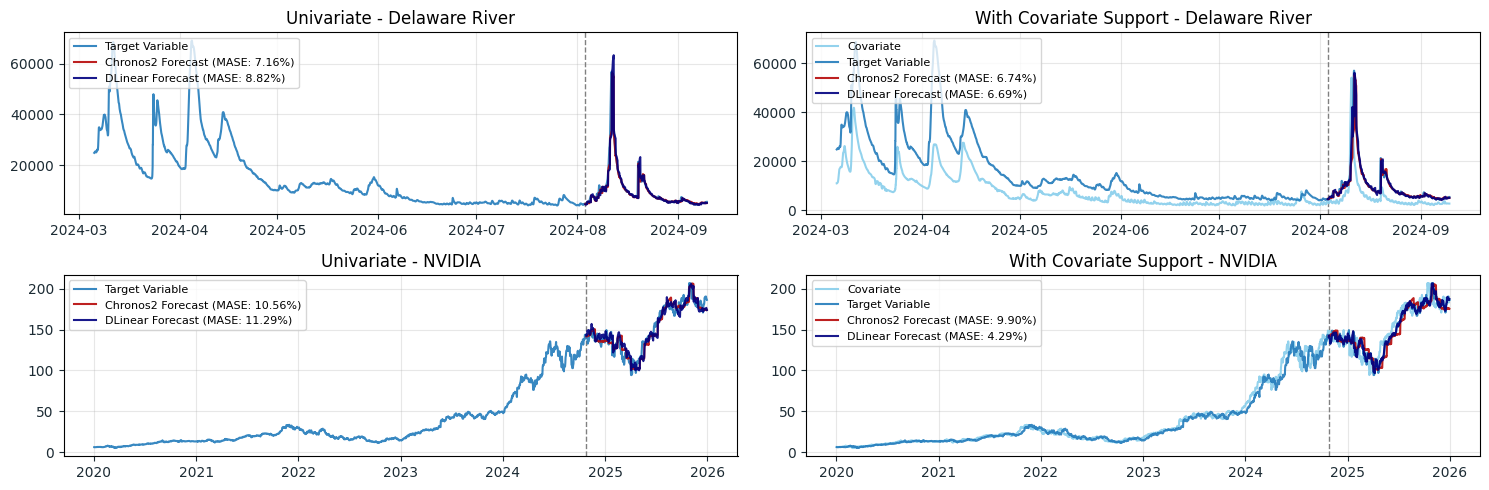

In [10]:
# Test set start = first row with a forecast
river_test_start = df_river["datetime"].iloc[df_river["forecast_chronos2_multivariate"].first_valid_index()]
nvidia_test_start = df_nvidia["Date"].iloc[df_nvidia["forecast_chronos2_multivariate"].first_valid_index()]

# Figsize aligned with visualization.py (e.g. polished_grid_plot uses (15, 5); 2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(15, 5))

# --- Row 0: Delaware River ---
x_r = df_river["datetime"]
# (0,0) Univariate
ax = axes[0, 0]
ax.axvline(river_test_start, color=GRAY, linestyle="--", linewidth=1)
ax.plot(x_r, df_river["Downstream_Trenton"], color=BLUE, label="Target Variable", alpha=0.9)
ax.plot(x_r, df_river["forecast_chronos2_univariate"], color=RED, label="Chronos2 Forecast (MASE: 7.16%)", alpha=0.9)
ax.plot(x_r, df_river["forecast_dlinear_univariate"], color=NAVY, label="DLinear Forecast (MASE: 8.82%)", alpha=0.9)
ax.legend(loc="upper left", fontsize=8)
ax.grid(which="both", alpha=0.3)
ax.tick_params(axis="x", color=DARK_GREY, labelcolor=DARK_GREY)
ax.tick_params(axis="y", color=DARK_GREY, labelcolor=DARK_GREY)
ax.set_title("Univariate - Delaware River")

# (0,1) With Covariate Support
ax = axes[0, 1]
ax.axvline(river_test_start, color=GRAY, linestyle="--", linewidth=1)
ax.plot(x_r, df_river["Upstream_Montague"], color=SKY_BLUE, label="Covariate", alpha=0.9)
ax.plot(x_r, df_river["Downstream_Trenton"], color=BLUE, label="Target Variable", alpha=0.9)
ax.plot(x_r, df_river["forecast_chronos2_multivariate"], color=RED, label="Chronos2 Forecast (MASE: 6.74%)", alpha=0.9)
ax.plot(x_r, df_river["forecast_dlinear_multivariate"], color=NAVY, label="DLinear Forecast (MASE: 6.69%)", alpha=0.9)
ax.legend(loc="upper left", fontsize=8)
ax.grid(which="both", alpha=0.3)
ax.tick_params(axis="x", color=DARK_GREY, labelcolor=DARK_GREY)
ax.tick_params(axis="y", color=DARK_GREY, labelcolor=DARK_GREY)
ax.set_title("With Covariate Support - Delaware River")

# --- Row 1: NVIDIA ---
x_n = df_nvidia["Date"]
# (1,0) Univariate
ax = axes[1, 0]
ax.axvline(nvidia_test_start, color=GRAY, linestyle="--", linewidth=1)
ax.plot(x_n, df_nvidia["Close amount"], color=BLUE, label="Target Variable", alpha=0.9)
ax.plot(x_n, df_nvidia["forecast_chronos2_univariate"], color=RED, label="Chronos2 Forecast (MASE: 10.56%)", alpha=0.9)
ax.plot(x_n, df_nvidia["forecast_dlinear_univariate"], color=NAVY, label="DLinear Forecast (MASE: 11.29%)", alpha=0.9)
ax.legend(loc="upper left", fontsize=8)
ax.grid(which="both", alpha=0.3)
ax.tick_params(axis="x", color=DARK_GREY, labelcolor=DARK_GREY)
ax.tick_params(axis="y", color=DARK_GREY, labelcolor=DARK_GREY)
ax.set_title("Univariate - NVIDIA")

# (1,1) With Covariate Support
ax = axes[1, 1]
ax.axvline(nvidia_test_start, color=GRAY, linestyle="--", linewidth=1)
ax.plot(x_n, df_nvidia["Close amount 16-step leak"], color=SKY_BLUE, label="Covariate", alpha=0.9)
ax.plot(x_n, df_nvidia["Close amount"], color=BLUE, label="Target Variable", alpha=0.9)
ax.plot(x_n, df_nvidia["forecast_chronos2_multivariate"], color=RED, label="Chronos2 Forecast (MASE: 9.90%)", alpha=0.9)
ax.plot(x_n, df_nvidia["forecast_dlinear_multivariate"], color=NAVY, label="DLinear Forecast (MASE: 4.29%)", alpha=0.9)
ax.legend(loc="upper left", fontsize=8)
ax.grid(which="both", alpha=0.3)
ax.tick_params(axis="x", color=DARK_GREY, labelcolor=DARK_GREY)
ax.tick_params(axis="y", color=DARK_GREY, labelcolor=DARK_GREY)
ax.set_title("With Covariate Support - NVIDIA")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=45)
#fig.suptitle("Delaware River (top row)  |  NVIDIA (bottom row)", y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig("real_data_plots.pdf", bbox_inches="tight")
plt.show()

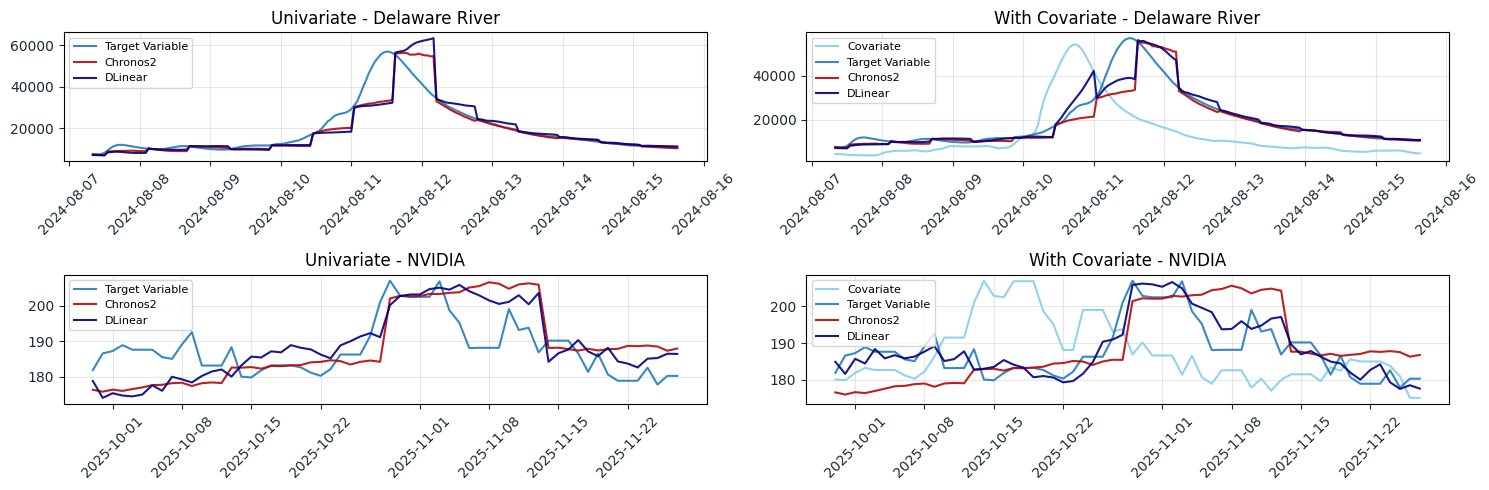

In [18]:
# Zoom into highest peak during test period (4 subplots, same layout)
# River: ±100 hours. X-axis: peak ± period (centered on peak, not test start)
r_test_start = df_river["forecast_chronos2_multivariate"].first_valid_index()
n_test_start = df_nvidia["forecast_chronos2_multivariate"].first_valid_index()

# Peak = argmax of target in test period
r_peak_idx = df_river.loc[r_test_start:, "Downstream_Trenton"].idxmax()
n_peak_idx = df_nvidia.loc[n_test_start:, "Close amount"].idxmax()

# Zoom window: ±100 hours for river, ±30 days for nvidia
r_window = 100
n_window = 30
r_zoom_start = max(0, r_peak_idx - r_window)
r_zoom_end = min(len(df_river), r_peak_idx + r_window)
n_zoom_start = max(0, n_peak_idx - n_window)
n_zoom_end = min(len(df_nvidia), n_peak_idx + n_window)

df_river_zoom = df_river.iloc[r_zoom_start:r_zoom_end]
df_nvidia_zoom = df_nvidia.iloc[n_zoom_start:n_zoom_end]

fig, axes = plt.subplots(2, 2, figsize=(15, 5))
x_r_z = df_river_zoom["datetime"]
x_n_z = df_nvidia_zoom["Date"]

# (0,0) River Univariate
ax = axes[0, 0]
#ax.axvline(river_test_start, color=GRAY, linestyle="--", linewidth=1)
ax.plot(x_r_z, df_river_zoom["Downstream_Trenton"], color=BLUE, label="Target Variable", alpha=0.9)
ax.plot(x_r_z, df_river_zoom["forecast_chronos2_univariate"], color=RED, label="Chronos2", alpha=0.9)
ax.plot(x_r_z, df_river_zoom["forecast_dlinear_univariate"], color=NAVY, label="DLinear", alpha=0.9)
ax.legend(loc="upper left", fontsize=8)
ax.grid(which="both", alpha=0.3)
ax.tick_params(axis="x", color=DARK_GREY, labelcolor=DARK_GREY)
ax.tick_params(axis="y", color=DARK_GREY, labelcolor=DARK_GREY)
ax.set_title("Univariate - Delaware River")

# (0,1) River With Covariate
ax = axes[0, 1]
#ax.axvline(river_test_start, color=GRAY, linestyle="--", linewidth=1)
ax.plot(x_r_z, df_river_zoom["Upstream_Montague"], color=SKY_BLUE, label="Covariate", alpha=0.9)
ax.plot(x_r_z, df_river_zoom["Downstream_Trenton"], color=BLUE, label="Target Variable", alpha=0.9)
ax.plot(x_r_z, df_river_zoom["forecast_chronos2_multivariate"], color=RED, label="Chronos2", alpha=0.9)
ax.plot(x_r_z, df_river_zoom["forecast_dlinear_multivariate"], color=NAVY, label="DLinear", alpha=0.9)
ax.legend(loc="upper left", fontsize=8)
ax.grid(which="both", alpha=0.3)
ax.tick_params(axis="x", color=DARK_GREY, labelcolor=DARK_GREY)
ax.tick_params(axis="y", color=DARK_GREY, labelcolor=DARK_GREY)
ax.set_title("With Covariate - Delaware River")

# (1,0) NVIDIA Univariate
ax = axes[1, 0]
#ax.axvline(nvidia_test_start, color=GRAY, linestyle="--", linewidth=1)
ax.plot(x_n_z, df_nvidia_zoom["Close amount"], color=BLUE, label="Target Variable", alpha=0.9)
ax.plot(x_n_z, df_nvidia_zoom["forecast_chronos2_univariate"], color=RED, label="Chronos2", alpha=0.9)
ax.plot(x_n_z, df_nvidia_zoom["forecast_dlinear_univariate"], color=NAVY, label="DLinear", alpha=0.9)
ax.legend(loc="upper left", fontsize=8)
ax.grid(which="both", alpha=0.3)
ax.tick_params(axis="x", color=DARK_GREY, labelcolor=DARK_GREY)
ax.tick_params(axis="y", color=DARK_GREY, labelcolor=DARK_GREY)
ax.set_title("Univariate - NVIDIA")

# (1,1) NVIDIA With Covariate
ax = axes[1, 1]
#ax.axvline(nvidia_test_start, color=GRAY, linestyle="--", linewidth=1)
ax.plot(x_n_z, df_nvidia_zoom["Close amount 16-step leak"], color=SKY_BLUE, label="Covariate", alpha=0.9)
ax.plot(x_n_z, df_nvidia_zoom["Close amount"], color=BLUE, label="Target Variable", alpha=0.9)
ax.plot(x_n_z, df_nvidia_zoom["forecast_chronos2_multivariate"], color=RED, label="Chronos2", alpha=0.9)
ax.plot(x_n_z, df_nvidia_zoom["forecast_dlinear_multivariate"], color=NAVY, label="DLinear", alpha=0.9)
ax.legend(loc="upper left", fontsize=8)
ax.grid(which="both", alpha=0.3)
ax.tick_params(axis="x", color=DARK_GREY, labelcolor=DARK_GREY)
ax.tick_params(axis="y", color=DARK_GREY, labelcolor=DARK_GREY)
ax.set_title("With Covariate - NVIDIA")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=45)
#fig.suptitle("Zoomed to highest peak in test period (River: ±100h, NVIDIA: ±30 days)", y=1.02, fontsize=11)
fig.tight_layout()
fig.savefig("real_data_plots_zoom_peak.pdf", bbox_inches="tight")
plt.show()